# HSLU Data Storytelling: Data Analysis

In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Ensure the export directory exists in Google Drive
export_drive_path = Path('/content/drive/My Drive/HSLU_Data_Storytelling/csv_exports/5_own_exports')
export_drive_path.mkdir(parents=True, exist_ok=True)

## 1. Prepare the Data

### 1.1 Load the Data

Source: https://www.americanson.ai/en/download

In [ ]:
file_id = '1B5hqbNJyCnrxOoBdcRTJdAxiHK2nOZBE'
url = f'https://drive.google.com/uc?id={file_id}'

try:
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()
    print("JSON successfully loaded from Google Drive:")
    print(json.dumps(data, indent=2))
except Exception as e:
    print(f"Error loading the JSON file{e}")

JSON successfully loaded from Google Drive:
{
  "schema_version": "dev",
  "study_id": "americans-on-ai",
  "title": "Americans on AI",
  "updated_at": "2026-09-16T00:00:00Z",
  "publisher": {
    "display_name": "Athena Insights",
    "url": "https://athenainsights.org",
    "roles": [
      "pollster",
      "publisher"
    ]
  },
  "contributors": [
    {
      "display_name": "NORC at the University of Chicago",
      "url": "https://www.norc.org",
      "roles": [
        "fielder"
      ]
    },
    {
      "display_name": "Prolific",
      "url": "https://www.prolific.com",
      "roles": [
        "fielder"
      ]
    }
  ],
  "methodology_notes": "Americans on AI is a tracking study of U.S. adults' views on artificial\nintelligence. The pilot wave (June 12-18, 2026) was fielded on the Prolific\nonline panel (nonprobability) and weighted by raking to American Community\nSurvey 2024 1-year benchmarks for sex, age, and race/ethnicity. Subsequent\nwaves are fielded by NORC at the

### 1.2 Data processing: JSON to DataFrame
We now transform the nested survey results into a tabular format (Tidy Data). In the process, we map subgroup codes to readable labels so that the subsequent analysis is easier.

The dataset contains 7,795 rows and 7 columns. Each row represents the result of a specific answer option for a given question in a specific subgroup at a specific time point (wave).

**Meaning of the columns:**
- `Wave`: The survey time point (e.g., pilot wave or monthly update).
- `Question_ID`: An internal identifier for the topic of the question (e.g., `ai_sentiment`).
- `Dimension`: The specific aspect or item of the question.
- `Full_Text`: The full wording of the question as presented to participants.
- `Subgroup`: The demographic group (e.g., `total`, `Men`, `Democrat`).
- `Answer`: The answer category (e.g., `very_excited`, `somewhat_concerned`).
- `Percentage`: The weighted share of responses in percent.


In [ ]:
# List for flattened records
flattened_data = []

# 1. Create a mapping from subgroup IDs to labels
subgroup_map = {}
if 'subgroup_schema' in data:
    for var in data['subgroup_schema']['variables']:
        for val in var['values']:
            subgroup_map[val['code']] = val['label']

# 2. Create a mapping for questions and dimensions
question_info = {}
for q in data.get('questions', []):
    q_id = q.get('id')
    q_stem = q.get('stem', '')

    if 'dimensions' in q:
        for dim in q['dimensions']:
            dim_id = dim.get('id')
            # Key logic: dimension ID or question ID
            full_id = f"{q_id}.{dim_id}" if dim_id != 'main' else q_id
            question_info[full_id] = {
                'text': f"{q_stem} {dim.get('text', '')}".strip(),
                'q_id': q_id,
                'dim_label': dim.get('label', dim.get('text'))
            }
    else:
        question_info[q_id] = {'text': q_stem, 'q_id': q_id, 'dim_label': None}

# 3. Extract data from the 'waves' list
waves_list = data.get('waves', [])

for wave_item in waves_list:
    wave_id = wave_item.get('wave_id', 'unknown')
    results = wave_item.get('results', [])

    for res_block in results:
        q_ref = res_block.get('question_id')
        dim_ref = res_block.get('dimension_id')
        lookup_key = f"{q_ref}.{dim_ref}" if dim_ref and dim_ref != 'main' else q_ref

        info = question_info.get(lookup_key, {'text': q_ref, 'q_id': q_ref, 'dim_label': dim_ref})
        subgroup_id = res_block.get('subgroup_id', 'total')

        dist = res_block.get('distribution', {})
        for entry in dist.get('entries', []):
            flattened_data.append({
                'Wave': wave_id,
                'Question_ID': info['q_id'],
                'Full_Question': info['text'],
                'Dimension': info['dim_label'],
                'Subgroup': subgroup_map.get(subgroup_id, subgroup_id),
                'Answer': entry.get('code'),
                'Percentage': entry.get('pct')
            })

# Create DataFrame
df_survey = pd.DataFrame(flattened_data)

print(f'Number of rows: {df_survey.shape[0]}')
print(f'Number of columns: {df_survey.shape[1]}')

if not df_survey.empty:
    display(df_survey.head(100))
else:
    print('No data found. Check the structure of "waves".')


Number of rows: 9176
Number of columns: 7


,Wave,Question_ID,Full_Question,Dimension,Subgroup,Answer,Percentage
0,2026-06-12,ai_sentiment,"Thinking about AI's growing role in society, w...","Thinking about AI's growing role in society, w...",total,very_excited,12.90
1,2026-06-12,ai_sentiment,"Thinking about AI's growing role in society, w...","Thinking about AI's growing role in society, w...",total,somewhat_excited,27.46
2,2026-06-12,ai_sentiment,"Thinking about AI's growing role in society, w...","Thinking about AI's growing role in society, w...",total,somewhat_concerned,35.58
3,2026-06-12,ai_sentiment,"Thinking about AI's growing role in society, w...","Thinking about AI's growing role in society, w...",total,very_concerned,22.28
4,2026-06-12,ai_sentiment,"Thinking about AI's growing role in society, w...","Thinking about AI's growing role in society, w...",total,none,1.78
...,...,...,...,...,...,...,...
95,2026-06-12,ai_community_impact,"Thinking about your local community, how much ...",People are saving time on everyday tasks,age_35_49,expect_soon,15.84
96,2026-06-12,ai_community_impact,"Thinking about your local community, how much ...",People are saving time on everyday tasks,age_35_49,dont_expect,8.79
97,2026-06-12,ai_community_impact,"Thinking about your local community, how much ...",People are saving time on everyday tasks,age_35_49,not_sure,7.08
98,2026-06-12,ai_community_impact,"Thinking about your local community, how much ...",People are saving time on everyday tasks,age_50_64,have_seen,35.65


## 2. Overview

### 2.1 Dimensions: Waves, Categories and Topics

Check the unique values, categories, and top patterns in the dataset to get an overview of the survey structure. This includes identifying the different waves, demographic subgroups, and question topics, as well as the unique answers used in the responses.

In [ ]:
print('Unique time points (waves)')
print(df_survey['Wave'].unique())

print('\nDemographic subgroup')
print(df_survey['Subgroup'].unique())

print('\nNumber of unique Topics')
print(df_survey['Question_ID'].unique())

print('\nUnique answers')
print(df_survey['Answer'].unique())


Unique time points (waves)
['2026-06-12' '2026-06-25' '2026-07-09' '2026-07-23' '2026-08-13'
 '2026-08-27' '2026-09-10']

Demographic subgroup
['total' 'gender_women' 'gender_men' 'party_dem' 'party_rep' 'age_18_34'
 'age_35_49' 'age_50_64' 'age_65_plus' 'race_white_nh' 'race_black_nh'
 'race_hispanic']

Number of unique Topics
['ai_sentiment' 'ai_agency' 'ai_community_impact' 'ai_family_impact'
 'ai_regulation' 'ai_risks']

Unique answers
['very_excited' 'somewhat_excited' 'somewhat_concerned' 'very_concerned'
 'none' 'can_shape' 'inevitable' 'have_seen' 'starting' 'expect_soon'
 'dont_expect' 'not_sure' 'much_better' 'somewhat_better' 'somewhat_worse'
 'much_worse' 'no_effect' 'way_too_much' 'somewhat_too_much'
 'right_amount' 'somewhat_too_little' 'way_too_little' 'already' 'likely'
 'unlikely' 'not_at_all_likely' 'no_answer' 'neither']


### Summary of the Dimension

By examining the unique values, we get an overview of the dimensions of the survey:

1.  **Time trend (Waves):** The dataset includes seven survey points between June and September 2026. This allows us to track trends in public opinion over a period of about three months.
2.  **Demographic diversity (Subgroups):** In addition to the overall population (`total`), the data are broken down by gender, political orientation, age, and ethnicity. This allows comparisons, for example, of whether men and women evaluate AI differently or whether there are differences between age groups.
3.  **Broad thematic coverage (Questions):** Six different core questions cover many aspects of AI, from general sentiment to specific risks such as the development of weapons of mass destruction.
4.  **Range of responses (Answer):** The responses range from agreement and probability to qualitative assessments. Important for data quality is also the presence of answers such as `not_sure` and `no_answer`.


### 2.2 Missing Values

Check for explicit null values in the DataFrame and identify `Missing` categories in the survey data (e.g., `no_answer` or `not_sure`).


In [ ]:
print('--- Technical null values (NaN) ---')
print(df_survey.isnull().sum())

# Filter for non-responses and uncertainty
missing_categories = ['no_answer', 'not_sure']
df_missing = df_survey[df_survey['Answer'].isin(missing_categories)]

missing_counts = df_missing['Answer'].value_counts()
total_rows = len(df_survey)

print('\n--- Analysis of response categories (Missing/Uncertain) ---')
for cat in missing_categories:
    count = missing_counts.get(cat, 0)
    percentage = (count / total_rows) * 100
    print(f"{cat}: {count} entries ({percentage:.2f}% of all rows)")


--- Technical null values (NaN) ---
Wave             0
Question_ID      0
Full_Question    0
Dimension        0
Subgroup         0
Answer           0
Percentage       0
dtype: int64

--- Analysis of response categories (Missing/Uncertain) ---
no_answer: 1329 entries (14.48% of all rows)
not_sure: 1053 entries (11.48% of all rows)


### Interpretation of Missing Values

When analyzing survey data, we need to distinguish between two types of 'missing' information:

1.  **Technical null values (NaN):** Our DataFrame is technically complete (0 null values). This means that the transformation process from the JSON file has worked cleanly and each row contains a valid data point.
2.  **Methodological non-response (Item Non-Response):** In social science surveys, it is important to capture cases where participants skip a question or do not want to answer:
    *   **`no_answer` (~14.3%):** This category includes people who skipped the question or refused to answer.
    *   **`not_sure` (~11.5%):** These participants took part but were uncertain about their opinion.


### 2.3 Notes Overview

In [ ]:
all_notes = []
for wi, w in enumerate(data.get("waves", [])):
    all_notes.append({
        "wave_idx": wi,
        "wave_id": w.get("wave_id"),
        "label": w.get("label"),
        "notes_path": f"root.waves[{wi}].notes",
        "notes": w.get("notes")
    })

for item in all_notes:
    print(item["notes_path"], " | ", item["wave_id"], " | ", item["label"])
    print(item["notes"])
    print()


root.waves[0].notes  |  2026-06-12  |  Pilot — June 12–18, 2026
Nonprobability pilot wave fielded on Prolific with forced-response items, so no item nonresponse appears. Party identification is respondent self-report (Democrat/Independent/Republican) without leaner allocation, unlike later waves where leaners fold into the parties. Race/ethnicity subgroups are not published for this wave: the panel's race categories cannot separate Hispanic ethnicity.

root.waves[1].notes  |  2026-06-25  |  June 2026
Fielded by NORC on the probability-based AmeriSpeak Panel in mixed mode (about 90% web, 10% phone). Item nonresponse is permitted from this wave: "No answer" categories absorb skipped and refused items. Party identification uses NORC's three-way party coding with leaners folded into the parties.

root.waves[2].notes  |  2026-07-09  |  July (W1) 2026
Fielded by NORC on the probability-based AmeriSpeak Panel in mixed mode (about 94% web, 6% phone). Item nonresponse is permitted: "No answer" 

# 3. Visualize

Create a simple visualization of the time trends. Start by filtering the data for the 'total' subgroup and the 'ai_sentiment' question, then create a visualization to show the longitudinal trend of public concern versus excitement.



### Use this notebook as a starting point to answer the following questions on your own:
-   Does AI sentiment differ significantly between political parties (`party_dem` vs. `party_rep`)?
-   Are younger people (`age_18_34`) actually more enthusiastic about AI than older generations (`age_65_plus`)?

Create your own questions :)

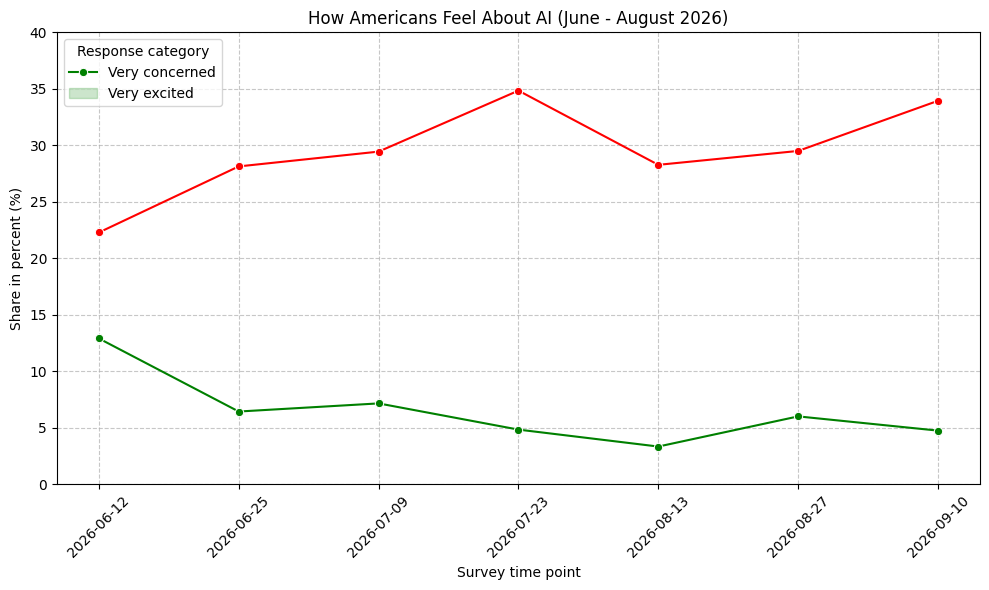

In [ ]:
# 1. Filter the data for the overall population and the general sentiment question
sentiment_total = df_survey[(df_survey['Question_ID'] == 'ai_sentiment') & (df_survey['Subgroup'] == 'total')]

# 2. Focus on the extreme categories: 'very_excited' and 'very_concerned'
plot_data = sentiment_total[sentiment_total['Answer'].isin(['very_excited', 'very_concerned'])]

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_data, x='Wave', y='Percentage', hue='Answer', marker='o', palette={'very_excited': 'green', 'very_concerned': 'red'})

plt.title('How Americans Feel About AI (June - August 2026)')
plt.xlabel('Survey time point')
plt.ylabel('Share in percent (%)')
plt.ylim(0, 40)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Response category', labels=['Very concerned', 'Very excited'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#4. Export

 Export your own CSV's for making a visual analysis with tools like https://www.datawrapper.de/, https://www.rawgraphs.io/ or https://www.tableau.com/products/desktop


Set the values in the next code cell to choose what to export.

Available filter values:
- **wave_value**
*'2026-06-12' '2026-06-25' '2026-07-09' '2026-07-23' '2026-08-13'
 '2026-08-27' '2026-09-10'*
- **subgroup_value**
*'total' 'gender_women' 'gender_men' 'party_dem' 'party_rep' 'age_18_34'
'age_35_49' 'age_50_64' 'age_65_plus' 'race_white_nh' 'race_black_nh'
'race_hispanic'*
- **question_id_value** *'ai_sentiment' 'ai_agency' 'ai_community_impact' 'ai_family_impact''ai_regulation' 'ai_risks'*

Leave a value empty if you do not want to filter by it.

You can combine them to export:
- only a wave
- only a subgroup
- only a question ID
- a wave and a subgroup
- a wave, subgroup, and question ID

In [41]:
wave_values = ['2026-09-10', '2026-07-23']  # example: ['2026-09-10'] or ['2026-09-10', '2026-07-23'] or []
subgroup_value = ['party_dem']  # example: ['total'] or ['party_dem', 'party_rep'] or []
question_id_value = []  # example: ['ai_sentiment'] or ['ai_sentiment', 'ai_regulation'] or []

# Updated export_dir to point to Google Drive
export_dir = Path('/content/drive/My Drive/HSLU_Data_Storytelling/csv_exports') / '5_own_exports'
export_dir.mkdir(parents=True, exist_ok=True)

export_df = df_survey.copy()

if wave_values:
    export_df = export_df[export_df['Wave'].isin(wave_values)]

if subgroup_value:
    export_df = export_df[export_df['Subgroup'].isin(subgroup_value)]

if question_id_value:
    export_df = export_df[export_df['Question_ID'].isin(question_id_value)]

parts = ['survey']
if wave_values:
    parts.append('waves_' + '-'.join(wave_values))

if subgroup_value:
    parts.append('subgroup_' + '-'.join(subgroup_value))

if question_id_value:
    parts.append('question_' + '-'.join(question_id_value))

file_path = export_dir / ('_'.join(parts) + '.csv')

export_df.to_csv(file_path, index=False, encoding='utf-8-sig')
print(f'Exported {len(export_df)} rows to {file_path}')

Exported 232 rows to /content/drive/My Drive/HSLU_Data_Storytelling/csv_exports/5_own_exports/survey_waves_2026-09-10-2026-07-23_subgroup_party_dem.csv
